## 1. Setup

In [ ]:
# 1.ipynb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn tools and preprocessing suites
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

Setup Complete


## 2. DataSet

In [ ]:
# local
# base_path = (
#     r"C:\Users\User\Documents\GitHub\template-kaggle-competition\housing-prices\data"
# )
# X_full = pd.read_csv(f"{base_path}\\train.csv", index_col="Id")
# X_test_full = pd.read_csv(f"{base_path}\\test.csv", index_col="Id")

# kaggle
X_full = pd.read_csv('/kaggle/input/competitions/home-data-for-ml-course/train.csv', index_col="Id")
X_test_full = pd.read_csv('/kaggle/input/competitions/home-data-for-ml-course/test.csv', index_col="Id")

# Remove data without target value
X_full.dropna(axis=0, subset=["SalePrice"], inplace=True)

# Objective variable logarithmic transformation
y_log = np.log1p(X_full.SalePrice)
X_full.drop(["SalePrice"], axis=1, inplace=True)

# For fields with missing values ​​that have actual physical meaning, fill in 'None' or 0
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
]

for col in none_cols:
    if col in X_full.columns:
        X_full[col] = X_full[col].fillna("None")
        X_test_full[col] = X_test_full[col].fillna("None")

zero_cols = [
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
]
for col in zero_cols:
    if col in X_full.columns:
        X_full[col] = X_full[col].fillna(0)
        X_test_full[col] = X_test_full[col].fillna(0)

# Displays the number of data entries and the number of columns.
print(f"Training set shape: {X_full.shape}")
print(f"Test set shape: {X_test_full.shape}")

訓練集形狀: (1460, 79)
測試集形狀: (1459, 79)


## 3. Feature Engineering

In [ ]:
def add_custom_features(df):
    df_out = df.copy()

    # Corrected MSSubClass format to class.
    if "MSSubClass" in df_out.columns:
        df_out["MSSubClass"] = df_out["MSSubClass"].astype(str)

    # Constant filling
    none_cols = [
        "PoolQC",
        "MiscFeature",
        "Alley",
        "Fence",
        "FireplaceQu",
        "GarageType",
        "GarageFinish",
        "GarageQual",
        "GarageCond",
        "BsmtQual",
        "BsmtCond",
        "BsmtExposure",
        "BsmtFinType1",
        "BsmtFinType2",
    ]
    for col in none_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna("None")

    zero_cols = [
        "GarageArea",
        "GarageCars",
        "BsmtFinSF1",
        "BsmtFinSF2",
        "BsmtUnfSF",
        "TotalBsmtSF",
        "BsmtFullBath",
        "BsmtHalfBath",
    ]
    for col in zero_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna(0)

    # 總居住面積 (TotalSF)
    df_out["TotalSF"] = df_out["TotalBsmtSF"] + df_out["1stFlrSF"] + df_out["2ndFlrSF"]
    # 總衛浴數 (TotalBaths)
    df_out["TotalBaths"] = (
        df_out["FullBath"]
        + (0.5 * df_out["HalfBath"])
        + df_out["BsmtFullBath"]
        + (0.5 * df_out["BsmtHalfBath"])
    )
    # 房屋屋齡與改建年數 (HouseAge, RemodAge)
    df_out["HouseAge"] = df_out["YrSold"] - df_out["YearBuilt"]
    df_out["RemodAge"] = df_out["YrSold"] - df_out["YearRemodAdd"]
    # 戶外總露台門廊面積 (TotalOutsideSF)
    df_out["TotalOutsideSF"] = (
        df_out["WoodDeckSF"]
        + df_out["OpenPorchSF"]
        + df_out["EnclosedPorch"]
        + df_out["3SsnPorch"]
        + df_out["ScreenPorch"]
    )
    return df_out


X_full_fe = add_custom_features(X_full)
X_test_full_fe = add_custom_features(X_test_full)

## 4. Feature clustering (numerical and categorical) and coding definition

In [ ]:
# Features of hierarchical order (Ordinal Features)
ordinal_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
]

# Define the ranking order (from Po=Poor to Ex=Excellent)
qual_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
ordinal_categories = [qual_order for _ in ordinal_cols]

# 無順序性的類別欄位 (低基數使用 One-Hot Encoding)[cite: 8, 9]
# cancel nunique() < 10 limitation，納入所有普通類別欄位
categorical_cols = [
    cname
    for cname in X_full_fe.columns
    if X_full_fe[cname].dtype == "object"
    and cname not in ordinal_cols
]

# Numeric fields
numerical_cols = [
    cname
    for cname in X_full_fe.columns
    if X_full_fe[cname].dtype in ["int64", "float64"]
]

# Preservation of feature set
my_cols = numerical_cols + ordinal_cols + categorical_cols
X = X_full_fe[my_cols].copy()
X_test = X_test_full_fe[my_cols].copy()

print(f"Selected numerical feature numbers: {len(numerical_cols)}")
print(f"Selected categorical feature numbers: {len(categorical_cols)}")

選取的數值特徵數: 40
選取的類別特徵數: 35


## 5. Data preprocessing pipeline

In [5]:
# 數值前處理：缺失值填補中位數 + 特徵縮放
num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# 有序類別前處理：OrdinalEncoder 按品質等級編碼[cite: 8, 9]
ord_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

# 無序類別前處理：OneHotEncoder 獨熱編碼[cite: 8, 9]
cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# 組合前處理器[cite: 9]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_cols),
        ("ord", ord_transformer, ordinal_cols),
        ("cat", cat_transformer, categorical_cols),
    ]
)

# 測試：兩者欄位數量與欄位名稱必須完全相同
print(f"X 訓練集特徵形狀: {X.shape}")
print(f"X 測試集特徵形狀: {X_test.shape}")
assert list(X.columns) == list(X_test.columns), "警告：訓練集與測試集的特徵欄位不一致！"

X 訓練集特徵形狀: (1460, 84)
X 測試集特徵形狀: (1459, 84)


## 6. 切分訓練集與驗證集

In [6]:
# 切分 80% 訓練集、20% 驗證集
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y_log, train_size=0.8, test_size=0.2, random_state=0
)

## 7. 訓練模型 與 比較 (Random Forest vs. XGBoost)

In [7]:
# 建立隨機森林 Pipeline
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", rf_model)])
rf_pipeline.fit(X_train, y_train) 

# 將預測結果轉回原型價格後計算 MAE
rf_preds = np.expm1(rf_pipeline.predict(X_valid))
rf_mae = mean_absolute_error(np.expm1(y_valid), rf_preds)
print(f"隨機森林 (Random Forest) Validation MAE: {rf_mae:,.2f}")

# 建立 XGBoost Pipeline
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=0)
xgb_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", xgb_model)])
xgb_pipeline.fit(X_train, y_train)

# 將預測結果轉回原型價格後計算 MAE
xgb_preds = np.expm1(xgb_pipeline.predict(X_valid))
xgb_mae = mean_absolute_error(np.expm1(y_valid), xgb_preds)
print(f"XGBoost Validation MAE: {xgb_mae:,.2f}")

隨機森林 (Random Forest) Validation MAE: 17,350.54
XGBoost Validation MAE: 17,328.13


## 8. 交叉驗證 與 超參數調優

In [8]:
# 定義 5 折交叉驗證計算 MAE[cite: 9]
def get_cv_score(n_estimators):
    model = XGBRegressor(
        n_estimators=n_estimators, learning_rate=0.05, max_depth=6, random_state=0
    )
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    # 使用 y_log 進行交叉驗證
    scores = -1 * cross_val_score(
        pipeline, X, y_log, cv=5, scoring="neg_mean_absolute_error"
    )
    return scores.mean()


# 測試不同的樹木數量
candidate_trees = [100, 250, 500, 750, 1000]
results = {n: get_cv_score(n) for n in candidate_trees}

for n, score in results.items():
    print(f"n_estimators={n} -> CV MAE: {score:,.2f}")

# 找出最佳參數
best_n_estimators = min(results, key=results.get)
print(
    f"\n最佳樹木數量: {best_n_estimators}，最低 MAE: {results[best_n_estimators]:,.2f}"
)

n_estimators=100 -> CV MAE: 0.09
n_estimators=250 -> CV MAE: 0.09
n_estimators=500 -> CV MAE: 0.09
n_estimators=750 -> CV MAE: 0.09
n_estimators=1000 -> CV MAE: 0.09

最佳樹木數量: 750，最低 MAE: 0.09


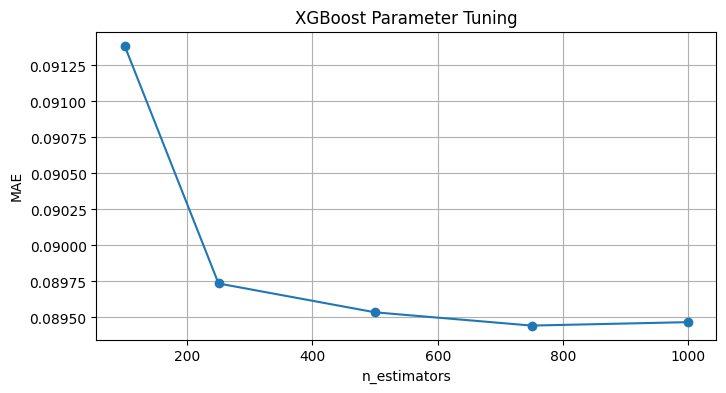

In [9]:
# 繪製參數調優趨勢圖
plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), marker="o")
plt.xlabel("n_estimators")
plt.ylabel("MAE")
plt.title("XGBoost Parameter Tuning")
plt.grid(True)
plt.show()

## 9. 全量資料重新訓練

In [10]:
# 使用最佳超參數定義最終模型
final_model = XGBRegressor(
    n_estimators=best_n_estimators, learning_rate=0.05, max_depth=6, random_state=0
)
final_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", final_model)]
)

# 使用全部資料 (X, y_log)進行訓練
final_pipeline.fit(X, y_log)
print("最終模型全量訓練完成！")

最終模型全量訓練完成！


## 10. 預測並匯出

In [11]:
# 對測試集預測後進行逆對數轉換 (expm1)
preds_test_log = final_pipeline.predict(X_test)
preds_test = np.expm1(preds_test_log)

print("測試集有無空值：", np.isnan(preds_test).any())
print("預測值描述統計：\n", pd.Series(preds_test).describe())

測試集有無空值： False
預測值描述統計：
 count      1459.000000
mean     177761.765625
std       75746.070312
min       46898.042969
25%      128724.242188
50%      158217.171875
75%      207776.625000
max      578100.500000
dtype: float64


In [12]:
output = pd.DataFrame({"Id": X_test.index, "SalePrice": preds_test})

# 存成 submission.csv
output.to_csv("submission.csv", index=False)
print("submission.csv 匯出成功！格式如下：")
print(output.head())

submission.csv 匯出成功！格式如下：
     Id      SalePrice
0  1461  123401.250000
1  1462  170288.093750
2  1463  176094.890625
3  1464  188095.703125
4  1465  187228.781250
